In [1]:
# DATA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML - KNN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load data
train_data = pd.read_csv('src/data/training.csv')
validation_data = pd.read_csv('src/data/validation.csv')
test_data = pd.read_csv('src/data/testing.csv')
train_data.dtypes
#data.shape

id                        object
name                      object
artists                   object
danceability             float64
energy                   float64
key                        int64
loudness                 float64
speechiness              float64
liveness                 float64
tempo                    float64
duration_ms                int64
year                       int64
genre                     object
avg_artist_popularity    float64
dtype: object

In [3]:
# Not direct edit on the source dataset
df = train_data.copy()

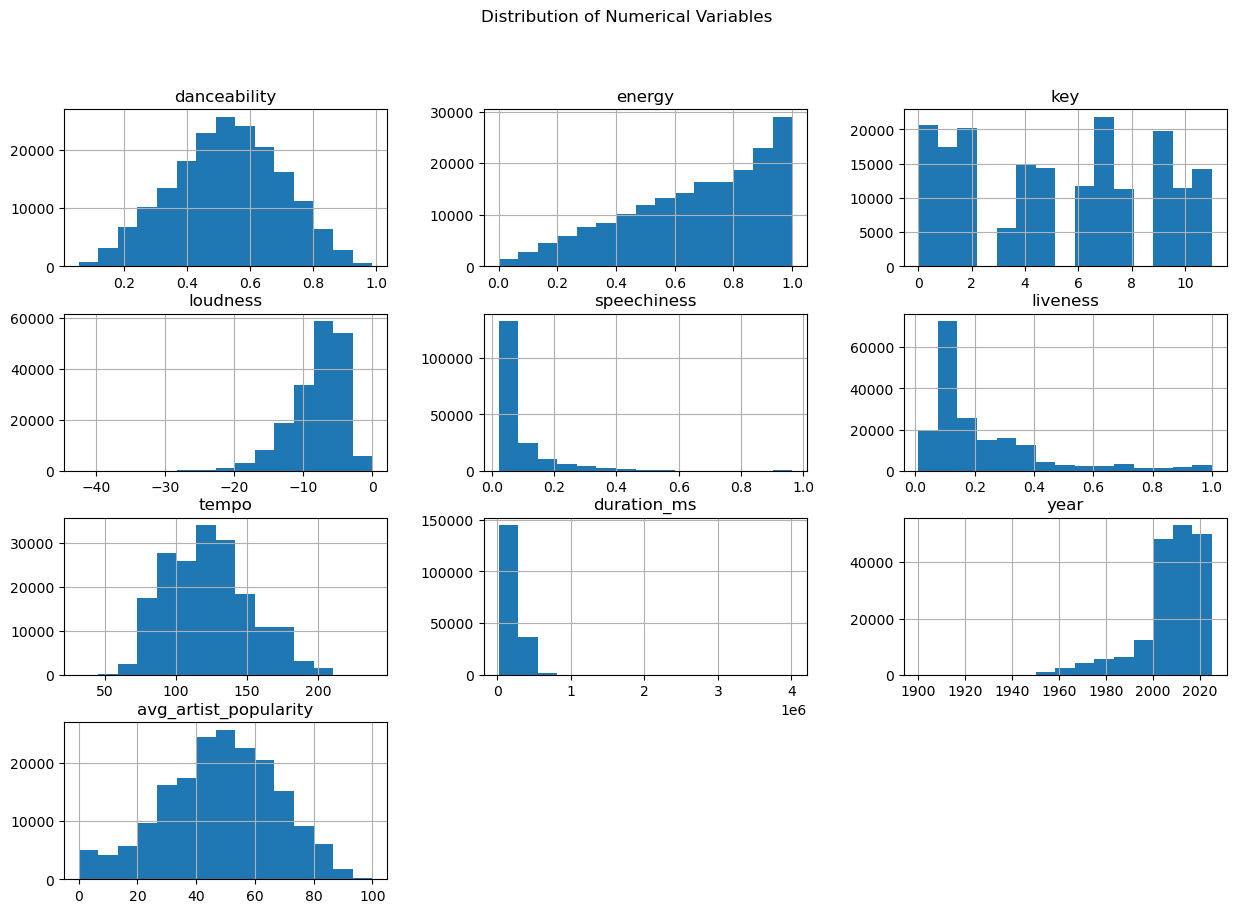


genre
Rock          65528
Pop           24166
Electronic    23192
Folk          16965
Country       15381
Hip-Hop       13874
R&B            9210
Jazz           5779
Blues          5405
Classical      4040
Name: count, dtype: int64

artists
["Elvis Presley"]      491
["Grateful Dead"]      474
["Aretha Franklin"]    396
["Bob Dylan"]          335
["Johnny Cash"]        265
Name: count, dtype: int64


In [4]:
numerical_cols = ['danceability', 'energy', 'key', 'loudness', 'speechiness', 'liveness', 'tempo', 'duration_ms', 'year', 'avg_artist_popularity']
df[numerical_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Variables')
plt.show()

# Frequency of categorical variables
print()
print(df['genre'].value_counts())

# Top 10 most frequent artists
print()
print(df['artists'].value_counts().head())

In [5]:
# Audio features used to represent the 'sound' of each track
audio_features = ['danceability', 'energy', 'key', 'loudness', 'speechiness', 'liveness', 'tempo', 'duration_ms', 'year']

# Build track pool from TRAIN data only
track_pool = train_data.drop_duplicates(subset='id').reset_index(drop=True)

# Feature matrix: one row per unique track
track_matrix = track_pool[audio_features]

In [6]:
from sklearn.preprocessing import StandardScaler
# StandardScaler

# Weight setting
feature_weights = {
    'danceability':      1.0,
    'energy':            3.0,
    'key':               0.3,
    'loudness':          1.0,
    'speechiness':       0.5,
    'liveness':          1.5,
    'tempo':             0.5,
    'duration_ms':       0.3,
    'year':              0.5
}

# Normalization — fit on TRAIN data only
scaler = StandardScaler(with_mean=True, with_std=True)
track_matrix_scaled = pd.DataFrame(
    scaler.fit_transform(track_pool[audio_features]),
    columns=audio_features
)

weights = np.array([feature_weights[f] for f in audio_features])
track_matrix_weighted = track_matrix_scaled * weights

# Prepare validation set — transform
val_pool = validation_data.drop_duplicates(subset='id').reset_index(drop=True)
val_matrix_scaled = pd.DataFrame(
    scaler.transform(val_pool[audio_features]),
    columns=audio_features
)
val_matrix_weighted = val_matrix_scaled * weights

# Prepare test set — transform
test_pool = test_data.drop_duplicates(subset='id').reset_index(drop=True)
test_matrix_scaled = pd.DataFrame(
    scaler.transform(test_pool[audio_features]),
    columns=audio_features
)
test_matrix_weighted = test_matrix_scaled * weights

scaler.mean_

array([ 5.27332496e-01,  6.70965291e-01,  5.27641386e+00, -7.88251655e+00,
        8.54913359e-02,  2.24048807e-01,  1.22818024e+02,  2.37284549e+05,
        2.00711414e+03])

In [7]:
scaler.scale_

array([1.72371906e-01, 2.45456918e-01, 3.55274681e+00, 3.85684191e+00,
       9.32953002e-02, 1.97055543e-01, 2.94469738e+01, 9.65434258e+04,
       1.36186277e+01])

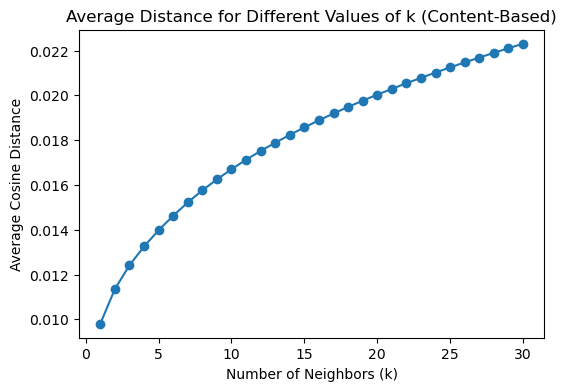

Suggested value of k: 29


In [8]:
# Discover K value using VALIDATION data
from sklearn.neighbors import NearestNeighbors

# K Value Range
k_values = list(range(1, 31))
mean_distances = []

# Find the best k — fit on train, evaluate distance on validation
for k in k_values:
    model = NearestNeighbors(n_neighbors=k, metric='cosine') #cosine #euclidean
    model.fit(track_matrix_weighted)

    # Sample from VALIDATION set (not train) to avoid overfitting k
    sample = val_matrix_weighted.sample(n=min(500, len(val_matrix_weighted)), random_state=376)
    distances, indices = model.kneighbors(sample)

    # Calculate the average distance to the nearest neighbors
    mean_distance = np.mean(distances)
    mean_distances.append(mean_distance)

# Plotting the average distance metric for different values of k
plt.figure(figsize=(6, 4))
plt.plot(k_values, mean_distances, marker='o')
plt.title('Average Distance for Different Values of k (Content-Based)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Cosine Distance')
plt.show()

# Find the best k - elbow point where distance stops dropping sharply
best_k = k_values[np.argmin(np.diff(mean_distances))]
print(f"Suggested value of k: {best_k}")

In [9]:
user_track_ids =['7qiZfU4dY1lWllzX7mPBI3',
           '66qlqxhEMpSHOzjRK4il0b',
           '1Vs6quoW1jxIb4HLlgVzO5',
           '3bNv3VuUOKgrf5hu3YcuRo',
           '0DuWDLjriRPjDRoPgaCslY',
           '0ClPIeT6MSgfSgQ9ZrJbAq',
           '4B1cHpLjzKUSm7LYGmxInZ',
           '3rXH3lBfuQVG9qwpANKWHt',
           '0tgVpDi06FyKpA1z0VMD4v',
           '7n2G21wCsM4OkuEAirxKId',
            ]

In [17]:
# KNN Recommendation scoring
# similarity_score = similarity * 0.90
# niche_bonus = 0.04 if similarity > 0.82 and pop < 50 and >= 20
# popularity_bonus = 0.04 if similarity > 0.82 and pop >= 70
# artist_bonus = artist_match * 0.02

# 1. Resolve user tracks from the training pool
user_tracks = track_pool[track_pool['id'].isin(user_track_ids)].reset_index(drop=True)
print("User Input Songs:")
print(user_tracks[['name', 'artists', 'genre', 'avg_artist_popularity']].to_string(index=False))

# Genres and artists present in the user's input
user_genres  = set(user_tracks['genre'].unique())
user_artists = set(user_tracks['artists'].unique())
print(f"\nGenre filter:  {user_genres}")
print(f"Artist filter: {user_artists}")

# 2. Build a single query vector: centroid of the user's tracks in weighted feature space
user_indices = track_pool.index[track_pool['id'].isin(user_track_ids)].tolist()
user_vecs    = track_matrix_weighted.iloc[user_indices].values
query_vec    = user_vecs.mean(axis=0).reshape(1, -1)

# 3. Ask KNN for ALL tracks so we can rank the full pool
distances, rec_indices = model.kneighbors(
    pd.DataFrame(query_vec, columns=audio_features),
    n_neighbors=len(track_pool)
)
similarity_scores = 1 - distances[0]

# 4. Build candidate DataFrame in KNN rank order
candidates                     = track_pool.iloc[rec_indices[0]].copy().reset_index(drop=True)
candidates['similarity_score'] = similarity_scores
candidates['artist_match']     = candidates['artists'].isin(user_artists).astype(float)

# 5. Scoring — conditional bonuses based on similarity threshold
high_sim = candidates['similarity_score'] > 0.82
low_pop  = candidates['avg_artist_popularity'] < 50

candidates['weighted_similarity'] = candidates['similarity_score'] * 0.90
candidates['niche_bonus']         = np.where(high_sim & low_pop,  0.04, 0.0)
candidates['popularity_bonus']    = np.where(high_sim & ~low_pop, 0.04, 0.0)
candidates['artist_bonus']        = candidates['artist_match'] * 0.02

candidates['final_score'] = (
    candidates['weighted_similarity'] +
    candidates['niche_bonus'] +
    candidates['popularity_bonus'] +
    candidates['artist_bonus']
)

# 6. Filter + deduplicate + rank
new_playlist = (
    candidates[
        ~candidates['id'].isin(user_track_ids) &
        candidates['genre'].isin(user_genres)
    ]
    .drop_duplicates(subset=['name', 'artists'])
    .sort_values('final_score', ascending=False)
    .head(best_k)
    .reset_index(drop=True)
)

User Input Songs:
                                 name               artists genre  avg_artist_popularity
                     Someone Like You             ["Adele"]   Pop                   85.0
                      Cheating on You      ["Charlie Puth"]   Pop                   82.0
                              Perfect        ["Ed Sheeran"]   Pop                   90.0
          Scarborough Fair / Canticle ["Simon & Garfunkel"]  Folk                   70.0
               Officially Missing You             ["Tamia"]   R&B                   66.0
Let It Be - Single Version / 2021 Mix       ["The Beatles"]  Rock                   85.0
                   Castle on the Hill        ["Ed Sheeran"]   Pop                   90.0
                         Shape of You        ["Ed Sheeran"]   Pop                   90.0
                     Love In The Dark             ["Adele"]   Pop                   85.0
      I Thought I Saw Your Face Today         ["She & Him"]   Pop                   71.0

Ge

In [19]:
print(f"Recommended Playlist ({len(new_playlist)} tracks)  [alpha={alpha}]:")
print(new_playlist[['name', 'artists', 'genre', 'avg_artist_popularity', 'final_score']].to_string(index=False))

print(f"\nAvg artist popularity — input songs: {user_tracks['avg_artist_popularity'].mean():.1f}")
print(f"Avg artist popularity — recommended: {new_playlist['avg_artist_popularity'].mean():.1f}")

Recommended Playlist (29 tracks)  [alpha=0.82]:
                                              name                       artists genre  avg_artist_popularity  final_score
                                    Through It All              ["Charlie Puth"]   Pop                   82.0     0.954508
                                            Deeper                     ["Tamia"]   R&B                   66.0     0.948599
                                            Got Me                 ["She & Him"]   Pop                   71.0     0.947023
                                  Someone Like You                     ["Adele"]   Pop                   85.0     0.945639
                                        Easy On Me                     ["Adele"]   Pop                   85.0     0.944441
                                         All I Ask                     ["Adele"]   Pop                   85.0     0.940554
                       Hold Me, Thrill Me, Kiss Me                 ["She & Him"]   Pop     

In [20]:
# Save recommended playlist to CSV
output_path = 'recommended_playlist.csv'

export = new_playlist[['name', 'artists', 'genre', 'avg_artist_popularity', 'final_score']].copy()
export['artists'] = export['artists'].str.strip('["').str.strip('"]')
export.index += 1
export.index.name = '#'
export.columns = ['Name', 'Artist', 'Genre', 'Popularity', 'Score']

export.to_csv(output_path, encoding='utf-8')
print(f"Saved to {output_path}")


Saved to recommended_playlist.csv


In [21]:
# Final evaluation on TEST data — run once after all tuning is done
test_sample = test_matrix_weighted.sample(n=min(500, len(test_matrix_weighted)), random_state=376)
distances_test, _ = model.kneighbors(test_sample)
print(f"Test set avg cosine distance (k={best_k}): {np.mean(distances_test):.4f}")

Test set avg cosine distance (k=29): 0.0216


In [22]:
# Model Evaluation: Train / Validation / Test

def evaluate_split(query_pool, query_matrix, n_queries=200, seed=376):
    """Returns genre precision, RMSE, cosine similarity, and random baseline for a split."""
    idx = np.random.default_rng(seed).choice(
        len(query_pool), size=min(n_queries, len(query_pool)), replace=False
    )
    queries  = query_pool.iloc[idx].reset_index(drop=True)
    q_matrix = query_matrix.iloc[idx].reset_index(drop=True)

    genre_precisions        = []
    rmse_scores             = []
    cosine_sims             = []
    random_genre_precisions = []

    for i in range(len(queries)):
        query_vec   = q_matrix.iloc[[i]]
        query_genre = queries.iloc[i]['genre']

        dists, rec_indices = model.kneighbors(query_vec)
        recs = track_pool.iloc[rec_indices[0]]

        genre_precisions.append((recs['genre'] == query_genre).mean())
        cosine_sims.append(1 - np.mean(dists))

        rec_centroid = track_matrix_weighted.iloc[rec_indices[0]].mean().values
        rmse = np.sqrt(((query_vec.values[0] - rec_centroid) ** 2).mean())
        rmse_scores.append(rmse)

        random_recs = track_pool.sample(n=best_k, random_state=i)
        random_genre_precisions.append((random_recs['genre'] == query_genre).mean())

    return {
        'genre_precision':  np.mean(genre_precisions),
        'rmse':             np.mean(rmse_scores),
        'cosine_sim':       np.mean(cosine_sims),
        'random_precision': np.mean(random_genre_precisions),
    }

# Train queries come from track_pool — re-transform so evaluation is consistent
train_eval_matrix = pd.DataFrame(
    scaler.transform(track_pool[audio_features]), columns=audio_features
) * weights

splits = {
    'Train':      (track_pool,  train_eval_matrix),
    'Validation': (val_pool,    val_matrix_weighted),
    'Test':       (test_pool,   test_matrix_weighted),
}

results = {name: evaluate_split(pool, matrix) for name, (pool, matrix) in splits.items()}

# table
col_w = 13
header = f"{'Metric':<30}" + "".join(f"{name:>{col_w}}" for name in results)
print(header)
print("─" * len(header))

metrics = [
    ('genre_precision',  f'Genre Precision@{best_k}'),
    ('rmse',             'Avg RMSE (feature space)'),
    ('cosine_sim',       'Avg Cosine Similarity'),
    ('random_precision', 'Random Baseline Precision'),
]
for key, label in metrics:
    row = f"{label:<30}" + "".join(f"{results[s][key]:>{col_w}.4f}" for s in results)
    print(row)

print("─" * len(header))
lift_row = f"{'KNN over random':<30}"
for s in results:
    lift = results[s]['genre_precision'] / results[s]['random_precision']
    lift_row += f"{lift:>{col_w-1}.2f}x"
print(lift_row)

Metric                                Train   Validation         Test
─────────────────────────────────────────────────────────────────────
Genre Precision@29                   0.4220       0.3683       0.3518
Avg RMSE (feature space)             0.1832       0.1862       0.2002
Avg Cosine Similarity                0.9790       0.9785       0.9782
Random Baseline Precision            0.2105       0.1812       0.1855
─────────────────────────────────────────────────────────────────────
KNN over random                       2.00x        2.03x        1.90x


In [23]:
Peter_eng = ['7qiZfU4dY1lWllzX7mPBI3',
           '66qlqxhEMpSHOzjRK4il0b',
           '1Vs6quoW1jxIb4HLlgVzO5',
           '3bNv3VuUOKgrf5hu3YcuRo',
           '0DuWDLjriRPjDRoPgaCslY',
           '0ClPIeT6MSgfSgQ9ZrJbAq',
           '4B1cHpLjzKUSm7LYGmxInZ',
           '3rXH3lBfuQVG9qwpANKWHt',
           '0tgVpDi06FyKpA1z0VMD4v',
           '7n2G21wCsM4OkuEAirxKId',
            ]

Peter_korjpn = ['5vCuawHQ8Poch1odz9JDpB',
              '5IN9W6eUfk3014My9awagX',
              '3t723PlEADna6GjgquoMRW',
              '1IX47gefluXmKX4PrTBCRM',
              '0RDqNCRBGrSegk16Avfzuq',
              '0O9OnWm3z2B2TjvE051AMV',
              '3Hz3tTQwOdM6XkA0ALB2G9',
              '3pqgVtpnQbBAZoWT4AEm1B',
              '4pspYVQGFHLPEFgQPD1J7e',
              '67D4iZjmueDoQR9M1SWHw5',
             ]